# Periods and Period Arithmetic

**Periods** represent time *spans* — a whole day, month, quarter, or year — as opposed to the `Timestamp` objects from earlier notebooks, which each pin down a single *instant*. This is the "span of time" data type teased at the end of the previous notebook. The `pandas.Period` class represents it, and requires a string or integer plus a supported frequency:

In [1]:
import pandas as pd 
import numpy as np 

p = pd.Period("2011", freq="Y-DEC")

p

Period('2011', 'Y-DEC')

In this case, the `Period` object represents the full time span from January 1, 2011, to December 31, 2011, inclusive. Conveniently, adding and subtracting integers from periods has the effect of shifting them by their frequency — add 5 to a yearly period and you get 5 years later, not 5 days or 5 months:

In [2]:
p + 5

Period('2016', 'Y-DEC')

In [3]:
p - 2

Period('2009', 'Y-DEC')

If two periods have the same frequency, their difference is the number of units between them, expressed as a date offset (the same offset objects from the *Date Ranges, Frequencies, and Shifting* notebook):

In [4]:
pd.Period("2014", freq="Y-DEC") - p

<3 * YearEnds: month=12>

Regular ranges of periods can be constructed with the `period_range` function:

In [5]:
periods = pd.period_range("2000-01-01", "2000-06-30", freq="M")

periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

The `PeriodIndex` class stores a sequence of periods and can serve as an axis in any pandas data structure:

In [6]:
pd.Series(np.random.standard_normal(6), index=periods)

2000-01    0.709159
2000-02    1.301864
2000-03    0.875297
2000-04   -0.902926
2000-05   -0.246121
2000-06    0.928530
Freq: M, dtype: float64

If you have an array of period-like strings, you can construct a `PeriodIndex` directly from it, and every element becomes a `Period`:

In [7]:
values = ["2001Q3", "2002Q2", "2003Q1"]

index = pd.PeriodIndex(values, freq="Q-DEC")

index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

## Period Frequency Conversion

Periods and `PeriodIndex` objects can be converted to another frequency with their `asfreq` method. As an example, suppose we had an annual period and wanted to convert it into a monthly period either at the start or end of the year. This can be done like so:

In [8]:
p = pd.Period("2011", freq="Y-DEC")

p.asfreq("M", how="start")

Period('2011-01', 'M')

In [9]:
p.asfreq("M", how="end")

Period('2011-12', 'M')

In [10]:
p.asfreq("M")

Period('2011-12', 'M')

When `how` is omitted, `asfreq` defaults to `"end"` — that's why the line above matches `how="end"` rather than `how="start"`.

You can think of `Period("2011", "Y-DEC")` as being a sort of cursor for pointing to a span of time, subdivided by monthly periods (see the illustration below, right after the fiscal-year example).

For a **fiscal year** ending on a month other than December, the corresponding monthly subperiods are different:

In [11]:
p = pd.Period("2011", freq="Y-JUN")

p

Period('2011', 'Y-JUN')

In [12]:
p.asfreq("M", how="start")


Period('2010-07', 'M')

In [13]:
p.asfreq("M", how="end")

Period('2011-06', 'M')

In other words, the fiscal year labeled `"2011"` under `Y-JUN` covers **July 2010 through June 2011** — the label always names the calendar year the fiscal year *ends* in, not the one it starts in. That's worth sitting with for a second, because it's the source of the "which year does this belong to" confusion in the next example.

Here's that "cursor" picture made concrete for both cases — each annual `Period` subdivided into its 12 monthly subperiods, with `asfreq("M", how="start")` pointing at the first box and `asfreq("M", how="end")` pointing at the last:

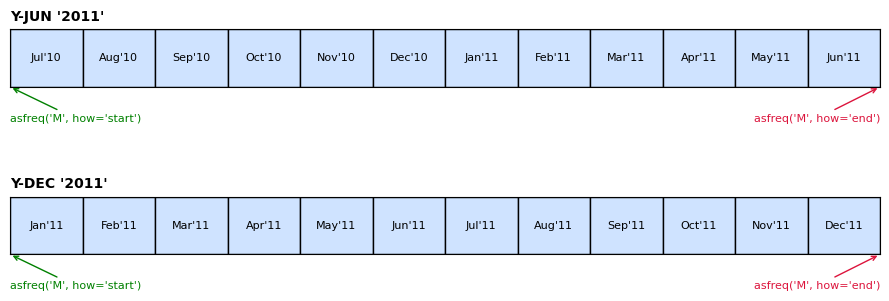

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 3.5), sharex=True)

configs = [
    ("Y-JUN '2011'", ["Jul'10", "Aug'10", "Sep'10", "Oct'10", "Nov'10", "Dec'10",
                       "Jan'11", "Feb'11", "Mar'11", "Apr'11", "May'11", "Jun'11"]),
    ("Y-DEC '2011'", ["Jan'11", "Feb'11", "Mar'11", "Apr'11", "May'11", "Jun'11",
                       "Jul'11", "Aug'11", "Sep'11", "Oct'11", "Nov'11", "Dec'11"]),
]

for ax, (title, months) in zip(axes, configs):
    ax.broken_barh([(i, 1) for i in range(12)], (0, 1), facecolors="#cfe3ff", edgecolors="black")
    for i, m in enumerate(months):
        ax.text(i + 0.5, 0.5, m, ha="center", va="center", fontsize=8)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(title, loc="left", fontsize=10, fontweight="bold")
    ax.annotate("asfreq('M', how='start')", xy=(0, 0), xytext=(0, -0.6), fontsize=8, ha="left",
                arrowprops=dict(arrowstyle="->", color="green"), color="green")
    ax.annotate("asfreq('M', how='end')", xy=(12, 0), xytext=(12, -0.6), fontsize=8, ha="right",
                arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")

plt.tight_layout()
plt.show()

When you're converting from high to low frequency, pandas determines the subperiod based on where the superperiod "belongs." For example, under `Y-JUN` frequency, the month `Aug-2011` is actually part of the `2012` fiscal year — because (per the label rule above) fiscal year `"2012"` runs July 2011 through June 2012, and August 2011 falls inside that window:

In [15]:
p = pd.Period("Aug-2011", "M")

p.asfreq("Y-JUN")

Period('2012', 'Y-JUN')

Whole `PeriodIndex` objects or time series can be similarly converted with the same semantics:

In [16]:
periods = pd.period_range("2006", "2009", freq="Y-DEC")

ts = pd.Series(np.random.standard_normal(len(periods)), index=periods)

ts 

2006    1.413086
2007   -1.350774
2008    1.565000
2009    1.524516
Freq: Y-DEC, dtype: float64

In [17]:
ts.asfreq("M", how="start")

2006-01    1.413086
2007-01   -1.350774
2008-01    1.565000
2009-01    1.524516
Freq: M, dtype: float64

Here the annual periods are replaced with monthly periods corresponding to the first month falling within each annual period. If we instead wanted the last business day of each year, we can convert to timestamps first and then use the `"B"` frequency to reindex onto every business day:

In [18]:
ts.to_timestamp(how="end").asfreq("B")

2007-01-01 23:59:59.999999         NaN
2007-01-02 23:59:59.999999         NaN
2007-01-03 23:59:59.999999         NaN
2007-01-04 23:59:59.999999         NaN
2007-01-05 23:59:59.999999         NaN
                                ...   
2009-12-25 23:59:59.999999         NaN
2009-12-28 23:59:59.999999         NaN
2009-12-29 23:59:59.999999         NaN
2009-12-30 23:59:59.999999         NaN
2009-12-31 23:59:59.999999    1.524516
Freq: B, Length: 784, dtype: float64

Don't be alarmed by the wall of `NaN`s — `Series.asfreq` **reindexes** onto every business day in the range, and we only ever had 4 actual data points (one per year). Every business day that isn't one of those 4 original timestamps has nothing to show, so it's `NaN`. The one real value that survives is on `2009-12-31`, which is both a business day and the last day of the last year in `ts`.

## Quarterly Period Frequencies

Quarterly data is standard in accounting, finance, and other fields. Much quarterly data is reported relative to a *fiscal year end*, typically the last calendar or business day of one of the 12 months of the year. Thus, the period `2012Q4` has a different meaning depending on the fiscal year end. `pandas` supports all 12 possible quarterly frequencies as `Q-JAN` through `Q-DEC`:

In [19]:
p = pd.Period("2012Q4", freq="Q-JAN")

p

Period('2012Q4', 'Q-JAN')

In the case of a fiscal year ending in January, `2012Q4` runs from November 2011 through January 2012, which you can check by converting to daily frequency:

In [20]:
p.asfreq("D", how="start")

Period('2011-11-01', 'D')

In [21]:
p.asfreq("D", how="end")

Period('2012-01-31', 'D')

Here's why fiscal year end matters so much for quarterly data: the same label, `"2012Q4"`, points at a completely different 3-month window depending on which of the 12 `Q-XXX` conventions you're using. `Q-JAN`'s `2012Q4` (shown above: Nov 2011–Jan 2012) is nowhere near `Q-DEC`'s `2012Q4` (Oct–Dec 2012):

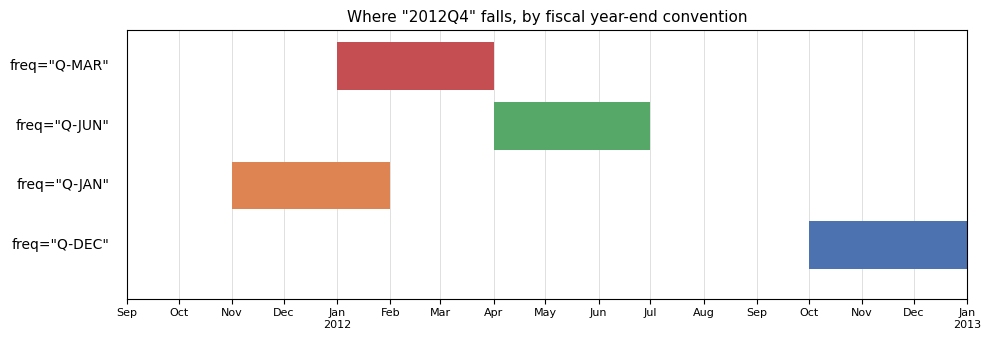

In [22]:
fig, ax = plt.subplots(figsize=(10, 3.5))

conventions = ["Q-DEC", "Q-JAN", "Q-JUN", "Q-MAR"]
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

timeline_start = pd.Timestamp("2011-09-01")
timeline_end = pd.Timestamp("2013-01-01")

for row, (freq, color) in enumerate(zip(conventions, colors)):
    q = pd.Period("2012Q4", freq=freq)
    start = q.asfreq("D", "start").to_timestamp()
    end = q.asfreq("D", "end").to_timestamp() + pd.Timedelta(days=1)
    start_days = (start - timeline_start).days
    width_days = (end - start).days
    ax.broken_barh([(start_days, width_days)], (row, 0.8), facecolors=color)
    ax.text(-10, row + 0.4, f'freq="{freq}"', ha="right", va="center", fontsize=10)

months = pd.date_range(timeline_start, timeline_end, freq="MS")
xticks = [(m - timeline_start).days for m in months]
xlabels = [m.strftime("%b\n%Y") if m.month == 1 else m.strftime("%b") for m in months]
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize=8)
ax.set_xlim(0, (timeline_end - timeline_start).days)
ax.set_ylim(-0.5, len(conventions))
ax.set_yticks([])
ax.set_title('Where "2012Q4" falls, by fiscal year-end convention', fontsize=11)
for x in xticks:
    ax.axvline(x, color="lightgray", linewidth=0.5, zorder=0)

plt.tight_layout()
plt.show()

Thus, it's possible to do convenient period arithmetic; for example, to get the timestamp at 4 P.M. on the second-to-last business day of the quarter, older material does this:

> **⚠️ Out of date:** the cell below intentionally still runs, but it raises a `FutureWarning` on current pandas. Combining a `Period`'s `"B"` (business day) frequency with arithmetic is deprecated, because `BusinessDay` isn't a fixed-length span the way a calendar day/month/year is (it "skips" weekends) — that doesn't fit the `Period` model of representing a clean, fixed span of time. pandas wants you to do this kind of business-day math on a `DatetimeIndex`/`Timestamp` with a `BDay` **offset** instead (see the *Date Ranges, Frequencies, and Shifting* notebook), not by giving a `Period` a business-day frequency. The warning is left visible here on purpose — a modern, warning-free rewrite follows right after:

In [23]:
p4pm = (p.asfreq("B", how="end") - 1).asfreq("min", how="start") + 16 * 60

p4pm

/var/folders/72/xf7wbb39361gc9hk7n78n1j00000gn/T/ipykernel_71685/3228916772.py:1: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (p.asfreq("B", how="end") - 1).asfreq("min", how="start") + 16 * 60


Period('2012-01-30 16:00', 'min')

In [24]:
p4pm.to_timestamp()

Timestamp('2012-01-30 16:00:00')

### Modern, warning-free equivalent

The `to_timestamp` method returns the `Timestamp` at the start of the period by default (that's why `p4pm.to_timestamp()` above didn't need `how=`, it was already an exact minute).

Here's the same "4pm on the second-to-last business day of the quarter" calculation done the recommended way — convert to a `Timestamp` first, then use the `BDay` offset directly instead of a `Period` with `"B"` frequency:

In [25]:
from pandas.tseries.offsets import BDay

end_of_quarter = p.asfreq("D", how="end").to_timestamp()  # last calendar day of the quarter
last_bday = BDay().rollback(end_of_quarter)                # roll back onto a business day if needed
second_to_last_bday = last_bday - BDay(1)

p4pm_modern = second_to_last_bday + pd.Timedelta(hours=16)
p4pm_modern

Timestamp('2012-01-30 16:00:00')

Same result (`2012-01-30 16:00:00`) as `p4pm.to_timestamp()` above, with no deprecation warning.

You can generate quarterly ranges using `pandas.period_range`, and the same arithmetic pattern applies to a whole `PeriodIndex` at once — including the same deprecated `"B"`-frequency path and warning:

In [26]:
periods = pd.period_range("2011Q3", "2012Q4", freq="Q-JAN")

ts = pd.Series(np.arange(len(periods)), index = periods)

ts

2011Q3    0
2011Q4    1
2012Q1    2
2012Q2    3
2012Q3    4
2012Q4    5
Freq: Q-JAN, dtype: int64

> **⚠️ Out of date:** same deprecation as before — `asfreq("B", ...)` on a `PeriodIndex` raises a `FutureWarning`. Left visible on purpose, modern rewrite follows.

In [27]:
new_periods = (periods.asfreq("B", "end") -1).asfreq("h", "start") + 16

/var/folders/72/xf7wbb39361gc9hk7n78n1j00000gn/T/ipykernel_71685/901558256.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_periods = (periods.asfreq("B", "end") -1).asfreq("h", "start") + 16


In [28]:
ts.index = new_periods.to_timestamp()

ts

2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int64

### Modern, warning-free equivalent

The same pattern as before, but vectorized over the whole `PeriodIndex` at once: convert every period's quarter-end to a `Timestamp`, roll each one back onto a business day with `.map()`, step back one more business day, then add the 4pm offset — no `Period` business-day frequency involved:

In [29]:
bday = BDay()
quarter_ends = periods.asfreq("D", "end").to_timestamp()
last_bdays = quarter_ends.map(bday.rollback)
new_index_modern = (last_bdays - BDay(1)) + pd.Timedelta(hours=16)

ts.index = new_index_modern
ts

2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int64

## Converting Timestamps to Periods (and Back)

Series and DataFrame objects indexed by timestamps can be converted to periods with the `to_period` method:

In [30]:
dates = pd.date_range("2000-01-01", periods=3, freq="ME")

ts = pd.Series(np.random.standard_normal(3), index=dates)

ts 

2000-01-31    0.457468
2000-02-29    1.613621
2000-03-31    1.805990
Freq: ME, dtype: float64

In [31]:
pts = ts.to_period()

pts

2000-01    0.457468
2000-02    1.613621
2000-03    1.805990
Freq: M, dtype: float64

Since periods refer to nonoverlapping time spans, a timestamp can only belong to a single period for a given frequency. While the frequency of the new `PeriodIndex` is inferred from the timestamps by default, you can specify any supported frequency. There is also no problem with having duplicate periods in the result:

In [32]:
dates = pd.date_range("2000-01-29", periods=6)

ts2 = pd.Series(np.random.standard_normal(6), index=dates)

ts2

2000-01-29   -0.949639
2000-01-30    0.167140
2000-01-31    0.390020
2000-02-01    0.298179
2000-02-02   -0.581190
2000-02-03   -0.024381
Freq: D, dtype: float64

In [33]:
ts2.to_period("M")

2000-01   -0.949639
2000-01    0.167140
2000-01    0.390020
2000-02    0.298179
2000-02   -0.581190
2000-02   -0.024381
Freq: M, dtype: float64

To convert back to timestamps, use the `to_timestamp()` method, which returns a `DatetimeIndex`.

**Nuance:** this round trip is *lossy* by default. `to_timestamp()` picks the *start* of each period unless you say `how="end"` — so `Timestamp → to_period() → to_timestamp()` won't generally give you back your original timestamps, just the start (or end) of whatever period they fell into. Compare `pts` (still holding the original daily timestamps, e.g. `23:59:59` isn't involved yet) against the `how="end"` conversion below, which pins every value to the very last microsecond of its day:

In [34]:
pts = ts2.to_period()

pts

2000-01-29   -0.949639
2000-01-30    0.167140
2000-01-31    0.390020
2000-02-01    0.298179
2000-02-02   -0.581190
2000-02-03   -0.024381
Freq: D, dtype: float64

In [35]:
pts.to_timestamp(how="end")

2000-01-29 23:59:59.999999   -0.949639
2000-01-30 23:59:59.999999    0.167140
2000-01-31 23:59:59.999999    0.390020
2000-02-01 23:59:59.999999    0.298179
2000-02-02 23:59:59.999999   -0.581190
2000-02-03 23:59:59.999999   -0.024381
Freq: D, dtype: float64

## Creating a PeriodIndex from Arrays

Fixed frequency datasets are sometimes stored with time span information spread across multiple columns. For example, in this macroeconomic dataset, the year and quarter are in different columns:

In [36]:
data = pd.read_csv("/Users/bmart231/DS/examples/macrodata.csv")

data.head(5)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [37]:
data["year"]

0      1959
1      1959
2      1959
3      1959
4      1960
       ... 
198    2008
199    2008
200    2009
201    2009
202    2009
Name: year, Length: 203, dtype: int64

In [38]:
data["quarter"]

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

By passing these arrays to `PeriodIndex.from_fields` with a frequency, you can combine them to form an index for the DataFrame.

> **⚠️ Out of date:** older material (and older pandas) constructs this by calling `pd.PeriodIndex(year=data["year"], quarter=data["quarter"], freq="Q-DEC")` directly. On current pandas that's not just deprecated — it's gone entirely, and raises `TypeError: PeriodIndex.__new__() got an unexpected keyword argument 'year'`. The `.from_fields(...)` classmethod below is the only supported way to build a `PeriodIndex` from separate field arrays now:

In [39]:
index = pd.PeriodIndex.from_fields(year=data["year"], quarter=data["quarter"], freq="Q-DEC")

index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

In [40]:
data.index = index

data["infl"]

1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

---

## Summary / Cheat Sheet

**`Period` vs `Timestamp`:** a `Period` is a *span* (all of March 2012); a `Timestamp` is an *instant* (March 5, 2012, 9:30:00am). `asfreq` moves a `Period` between frequencies; `to_period()` / `to_timestamp()` moves between the two types entirely.

| What you want | How |
|---|---|
| A single period | `pd.Period("2011", freq="Y-DEC")` |
| A range of periods | `pd.period_range(start, end, freq=...)` |
| Change a period's frequency | `p.asfreq(freq, how="start"/"end")` (defaults to `"end"`) |
| Timestamps → periods | `ts.to_period(freq)` |
| Periods → timestamps | `pts.to_timestamp(how="start"/"end")` (defaults to `"start"`) |
| Build a `PeriodIndex` from separate year/quarter columns | `pd.PeriodIndex.from_fields(year=..., quarter=..., freq=...)` |

**⚠️ Out of date on current pandas — don't copy these from older tutorials:**
- `Period`/`PeriodIndex` with a `"B"` (business day) frequency, and any arithmetic built on it — raises `FutureWarning`. Convert to a `Timestamp`/`DatetimeIndex` and use the `BDay` offset instead.
- `pd.PeriodIndex(year=..., quarter=..., freq=...)` — the keyword-argument constructor is gone. Use `pd.PeriodIndex.from_fields(...)`.

**Nuances worth remembering:**
- A fiscal year's label always names the year it *ends* in, not the one it starts in (`Y-JUN` period `"2011"` = July 2010–June 2011). This is what makes "which fiscal year does this month belong to" non-obvious when converting frequencies.
- `Timestamp → to_period() → to_timestamp()` is lossy by default: you get back the *start* of whatever period you landed in, not your original timestamp, unless you explicitly pass `how="end"` (and even then you land on the period's boundary, not your original time-of-day).
- `Series.asfreq(...)` **reindexes** — if your data is sparser than the target frequency, expect a lot of `NaN`, not an error.

**Up next:** *Resampling and Frequency Conversion* — converting an irregular or high-frequency time series onto a fixed, typically coarser, frequency (downsampling), the reverse (upsampling), and grouped time resampling.